# Visual Comparison — Ground Truth vs MuscleMap WB vs MuscleMap WB + MedSAM

Shows the same axial slice from three segmentation sources side by side,
overlaid on the raw water image.

| Color | Muscle |
|---|---|
| Red | Gracilis L (GT 1 / MM 7151 / NPZ Gracilis_L) |
| Blue | Gracilis R (GT 5 / MM 7152 / NPZ Gracilis_R) |
| Green | Sartorius L (GT 4 / MM 7141 / NPZ Sartorius_L) |
| Orange | Sartorius R (GT 8 / MM 7142 / NPZ Sartorius_R) |
| Light gray | All other segmented muscles |

In [1]:
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

In [10]:
# ── Configuration — change subject / stack here ───────────────────────────
SUBJECT = 'HV001_1'
STACK   = '1'

EVAL_DIR = r'C:\Projects\dissector\eval_notebooks'

IMAGE_PATH = rf'{EVAL_DIR}\myosegmenTUM\{SUBJECT}\ImageData\{SUBJECT}_WATER\{SUBJECT}_WATER_stack{STACK}.nii'
GT_PATH    = rf'{EVAL_DIR}\myosegmenTUM\{SUBJECT}\SegmentationMasks\combined_gt_stack{STACK}.mha'
MM_PATH    = rf'{EVAL_DIR}\muscle_map_wb\segs_water\{SUBJECT}_WATER_stack{STACK}_dseg.nii.gz'
SAM_PATH   = rf'{EVAL_DIR}\muscle_map_wb_boxes_medsam\segs_water\{SUBJECT}_WATER_stack{STACK}_mm_medsam.npz'
MASK_PATH  = rf'{EVAL_DIR}\muscle_map_wb_masks_medsam\segs_water\{SUBJECT}_WATER_stack{STACK}_mm_logitmask.npz'

ALPHA = 0.55

# Muscle colours — distinct from each other and from FP (red) / FN (blue).
MUSCLES = {
    'Gracilis L':  dict(gt=1, mm=7151, sam='Gracilis_L',  color=(1.00, 0.85, 0.00)),  # gold
    'Gracilis R':  dict(gt=5, mm=7152, sam='Gracilis_R',  color=(0.90, 0.15, 0.85)),  # magenta
    'Sartorius L': dict(gt=4, mm=7141, sam='Sartorius_L', color=(0.00, 0.85, 0.85)),  # cyan
    'Sartorius R': dict(gt=8, mm=7142, sam='Sartorius_R', color=(0.50, 0.95, 0.10)),  # lime
}
OTHER_COLOR = (0.72, 0.72, 0.72)

FP_COLOR = (0.95, 0.15, 0.15)
FN_COLOR = (0.20, 0.40, 1.00)

for p in [IMAGE_PATH, GT_PATH, MM_PATH, SAM_PATH, MASK_PATH]:
    print('exists:', os.path.exists(p), os.path.basename(p))

exists: True HV001_1_WATER_stack1.nii
exists: True combined_gt_stack1.mha
exists: True HV001_1_WATER_stack1_dseg.nii.gz
exists: True HV001_1_WATER_stack1_mm_medsam.npz
exists: True HV001_1_WATER_stack1_mm_logitmask.npz


In [11]:
img  = sitk.GetArrayFromImage(sitk.ReadImage(IMAGE_PATH)).astype(float)
gt   = sitk.GetArrayFromImage(sitk.ReadImage(GT_PATH)).astype(int)
mm   = sitk.GetArrayFromImage(sitk.ReadImage(MM_PATH)).astype(int)
npz  = np.load(SAM_PATH)
npz_mask = np.load(MASK_PATH)

print('Image shape:', img.shape)
print('GT unique labels:', np.unique(gt[gt > 0]))
print('MM unique labels:', np.unique(mm[mm > 0]))
print('SAM (bbox) keys:    ', sorted(npz.files))
print('SAM (logitmask) keys:', sorted(npz_mask.files))

Image shape: (65, 672, 672)
GT unique labels: [1 2 3 4 5 6 7 8]
MM unique labels: [5121 5122 6101 6102 6111 6112 6121 6122 6131 6132 6141 6142 6151 6152
 6160 6171 6172 6181 6182 6191 6192 6201 6202 6211 6212 6221 6222 7101
 7102 7111 7112 7121 7122 7131 7132 7141 7142 7151 7152 7161 7162 7171
 7172 7181 7182 7201 7202 7211 7212 7221 7222]
SAM (bbox) keys:     ['Adductor_Magnus_L', 'Adductor_Magnus_R', 'Biceps_Femoris_L', 'Biceps_Femoris_R', 'Gracilis_L', 'Gracilis_R', 'Rectus_Femoris_L', 'Rectus_Femoris_R', 'Sartorius_L', 'Sartorius_R', 'Semimembranosus_L', 'Semimembranosus_R', 'Semitendinosus_L', 'Semitendinosus_R', 'Vastus_Intermedius_L', 'Vastus_Intermedius_R', 'Vastus_Lateralis_L', 'Vastus_Lateralis_R', 'Vastus_Medialis_L', 'Vastus_Medialis_R']
SAM (logitmask) keys: ['Adductor_Magnus_L', 'Adductor_Magnus_R', 'Biceps_Femoris_L', 'Biceps_Femoris_R', 'Gracilis_L', 'Gracilis_R', 'Rectus_Femoris_L', 'Rectus_Femoris_R', 'Sartorius_L', 'Sartorius_R', 'Semimembranosus_L', 'Semimembranosus

In [12]:
# ── Find slice with most total GT segmented voxels ────────────────────────
gt_counts = np.array([(gt[i] > 0).sum() for i in range(gt.shape[0])])
best_slice = int(np.argmax(gt_counts))
print(f'Best slice: {best_slice}  ({gt_counts[best_slice]:,} GT voxels)')

# Also print top-5 options so you can pick a different slice manually
top5 = np.argsort(gt_counts)[::-1][:5]
for i in top5:
    print(f'  slice {i:3d}: {gt_counts[i]:,} voxels')

Best slice: 0  (38,246 GT voxels)
  slice   0: 38,246 voxels
  slice   1: 37,842 voxels
  slice   4: 36,219 voxels
  slice   5: 36,097 voxels
  slice   3: 36,076 voxels


In [13]:
# ── Override slice here if you want a specific one ────────────────────────
# best_slice = 30
pass

In [14]:
def blend_overlay(img_2d, masks_colors, alpha):
    """
    Blend a list of (mask_bool, rgb) tuples onto a grayscale image.
    Returns an (H, W, 3) float image in [0, 1].
    """
    img_norm = (img_2d - img_2d.min()) / (img_2d.max() - img_2d.min() + 1e-8)
    out = np.stack([img_norm] * 3, axis=-1).copy()
    for mask, color in masks_colors:
        if mask is None or not mask.any():
            continue
        for c in range(3):
            out[mask, c] = out[mask, c] * (1 - alpha) + color[c] * alpha
    return out


def gt_masks_colors(sl):
    """Build (mask, color) list for the GT slice."""
    known_gt = {m['gt'] for m in MUSCLES.values()}
    other = (sl > 0) & ~np.isin(sl, list(known_gt))
    mc = [(other, OTHER_COLOR)]
    for name, m in MUSCLES.items():
        mc.append(((sl == m['gt']), m['color']))
    return mc


def mm_masks_colors(sl):
    """Build (mask, color) list for the MM WB slice."""
    known_mm = {m['mm'] for m in MUSCLES.values()}
    other = (sl > 0) & ~np.isin(sl, list(known_mm))
    mc = [(other, OTHER_COLOR)]
    for name, m in MUSCLES.items():
        mc.append(((sl == m['mm']), m['color']))
    return mc


def sam_masks_colors(npz, sl_idx):
    """Build (mask, color) list for the MedSAM NPZ slice."""
    known_keys = {m['sam'] for m in MUSCLES.values()}
    other = np.zeros(npz[npz.files[0]].shape[1:], dtype=bool)
    for key in npz.files:
        if key not in known_keys:
            other |= npz[key][sl_idx].astype(bool)
    mc = [(other, OTHER_COLOR)]
    for name, m in MUSCLES.items():
        key = m['sam']
        mask = npz[key][sl_idx].astype(bool) if key in npz.files else None
        mc.append((mask, m['color']))
    return mc


def label_ax(ax, text):
    ax.text(0.02, 0.97, text, transform=ax.transAxes,
            fontsize=11, fontweight='bold', color='white',
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.65))


print('Overlay helpers defined.')

Overlay helpers defined.


Saved: comparison_HV001_1_stack1_slice0.png


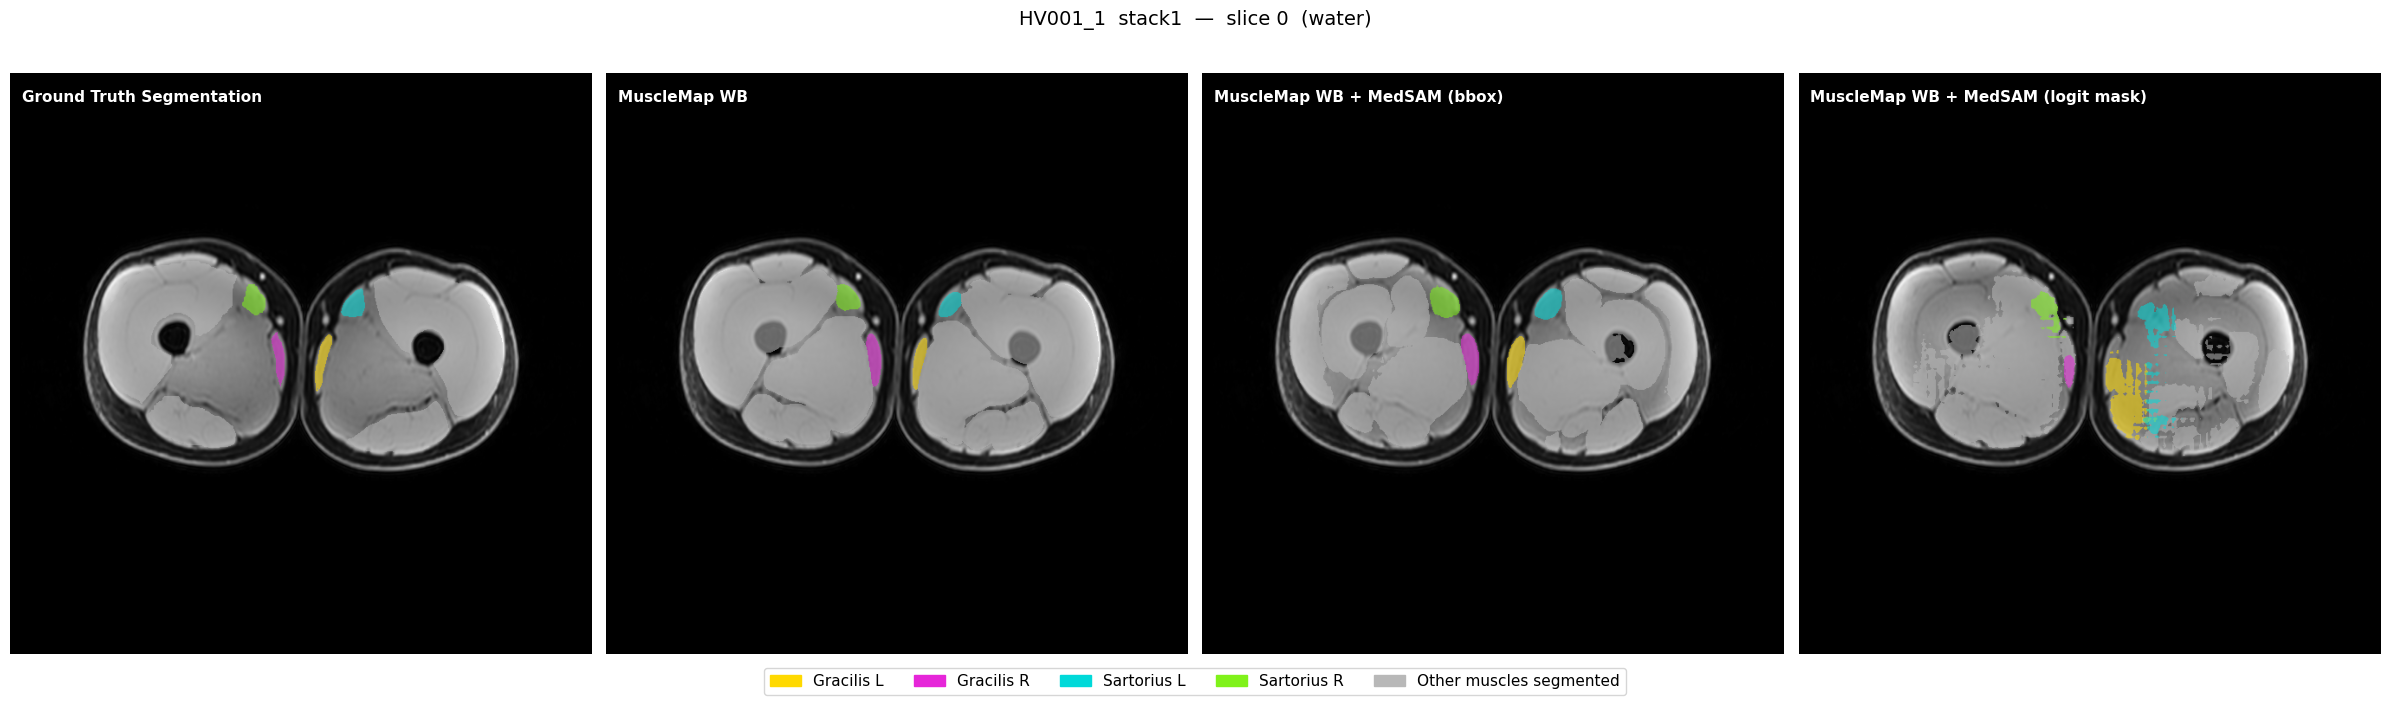

In [15]:
img_sl = img[best_slice]
gt_sl  = gt[best_slice]
mm_sl  = mm[best_slice]

gt_rgb   = blend_overlay(img_sl, gt_masks_colors(gt_sl),                ALPHA)
mm_rgb   = blend_overlay(img_sl, mm_masks_colors(mm_sl),                ALPHA)
sam_rgb  = blend_overlay(img_sl, sam_masks_colors(npz,      best_slice), ALPHA)
mask_rgb = blend_overlay(img_sl, sam_masks_colors(npz_mask, best_slice), ALPHA)

panels = [
    (gt_rgb,   'Ground Truth Segmentation'),
    (mm_rgb,   'MuscleMap WB'),
    (sam_rgb,  'MuscleMap WB + MedSAM (bbox)'),
    (mask_rgb, 'MuscleMap WB + MedSAM (logit mask)'),
]

fig, axes = plt.subplots(1, 4, figsize=(24, 7))
for ax, (rgb, label) in zip(axes, panels):
    ax.imshow(rgb, origin='upper')
    ax.axis('off')
    label_ax(ax, label)

muscle_patches = [mpatches.Patch(color=m['color'], label=name) for name, m in MUSCLES.items()]
muscle_patches.append(mpatches.Patch(color=OTHER_COLOR, label='Other muscles segmented'))
fig.legend(handles=muscle_patches, loc='lower center', ncol=5,
           fontsize=11, bbox_to_anchor=(0.5, -0.01))

plt.suptitle(f'{SUBJECT}  stack{STACK}  —  slice {best_slice}  (water)', fontsize=14)
plt.tight_layout()
out_png = f'comparison_{SUBJECT}_stack{STACK}_slice{best_slice}.png'
plt.savefig(out_png, dpi=150, bbox_inches='tight')
print('Saved:', out_png)
plt.show()

Worst slices: [51, 29, 27]
Saved: comparison_HV001_1_stack1_mismatch.png


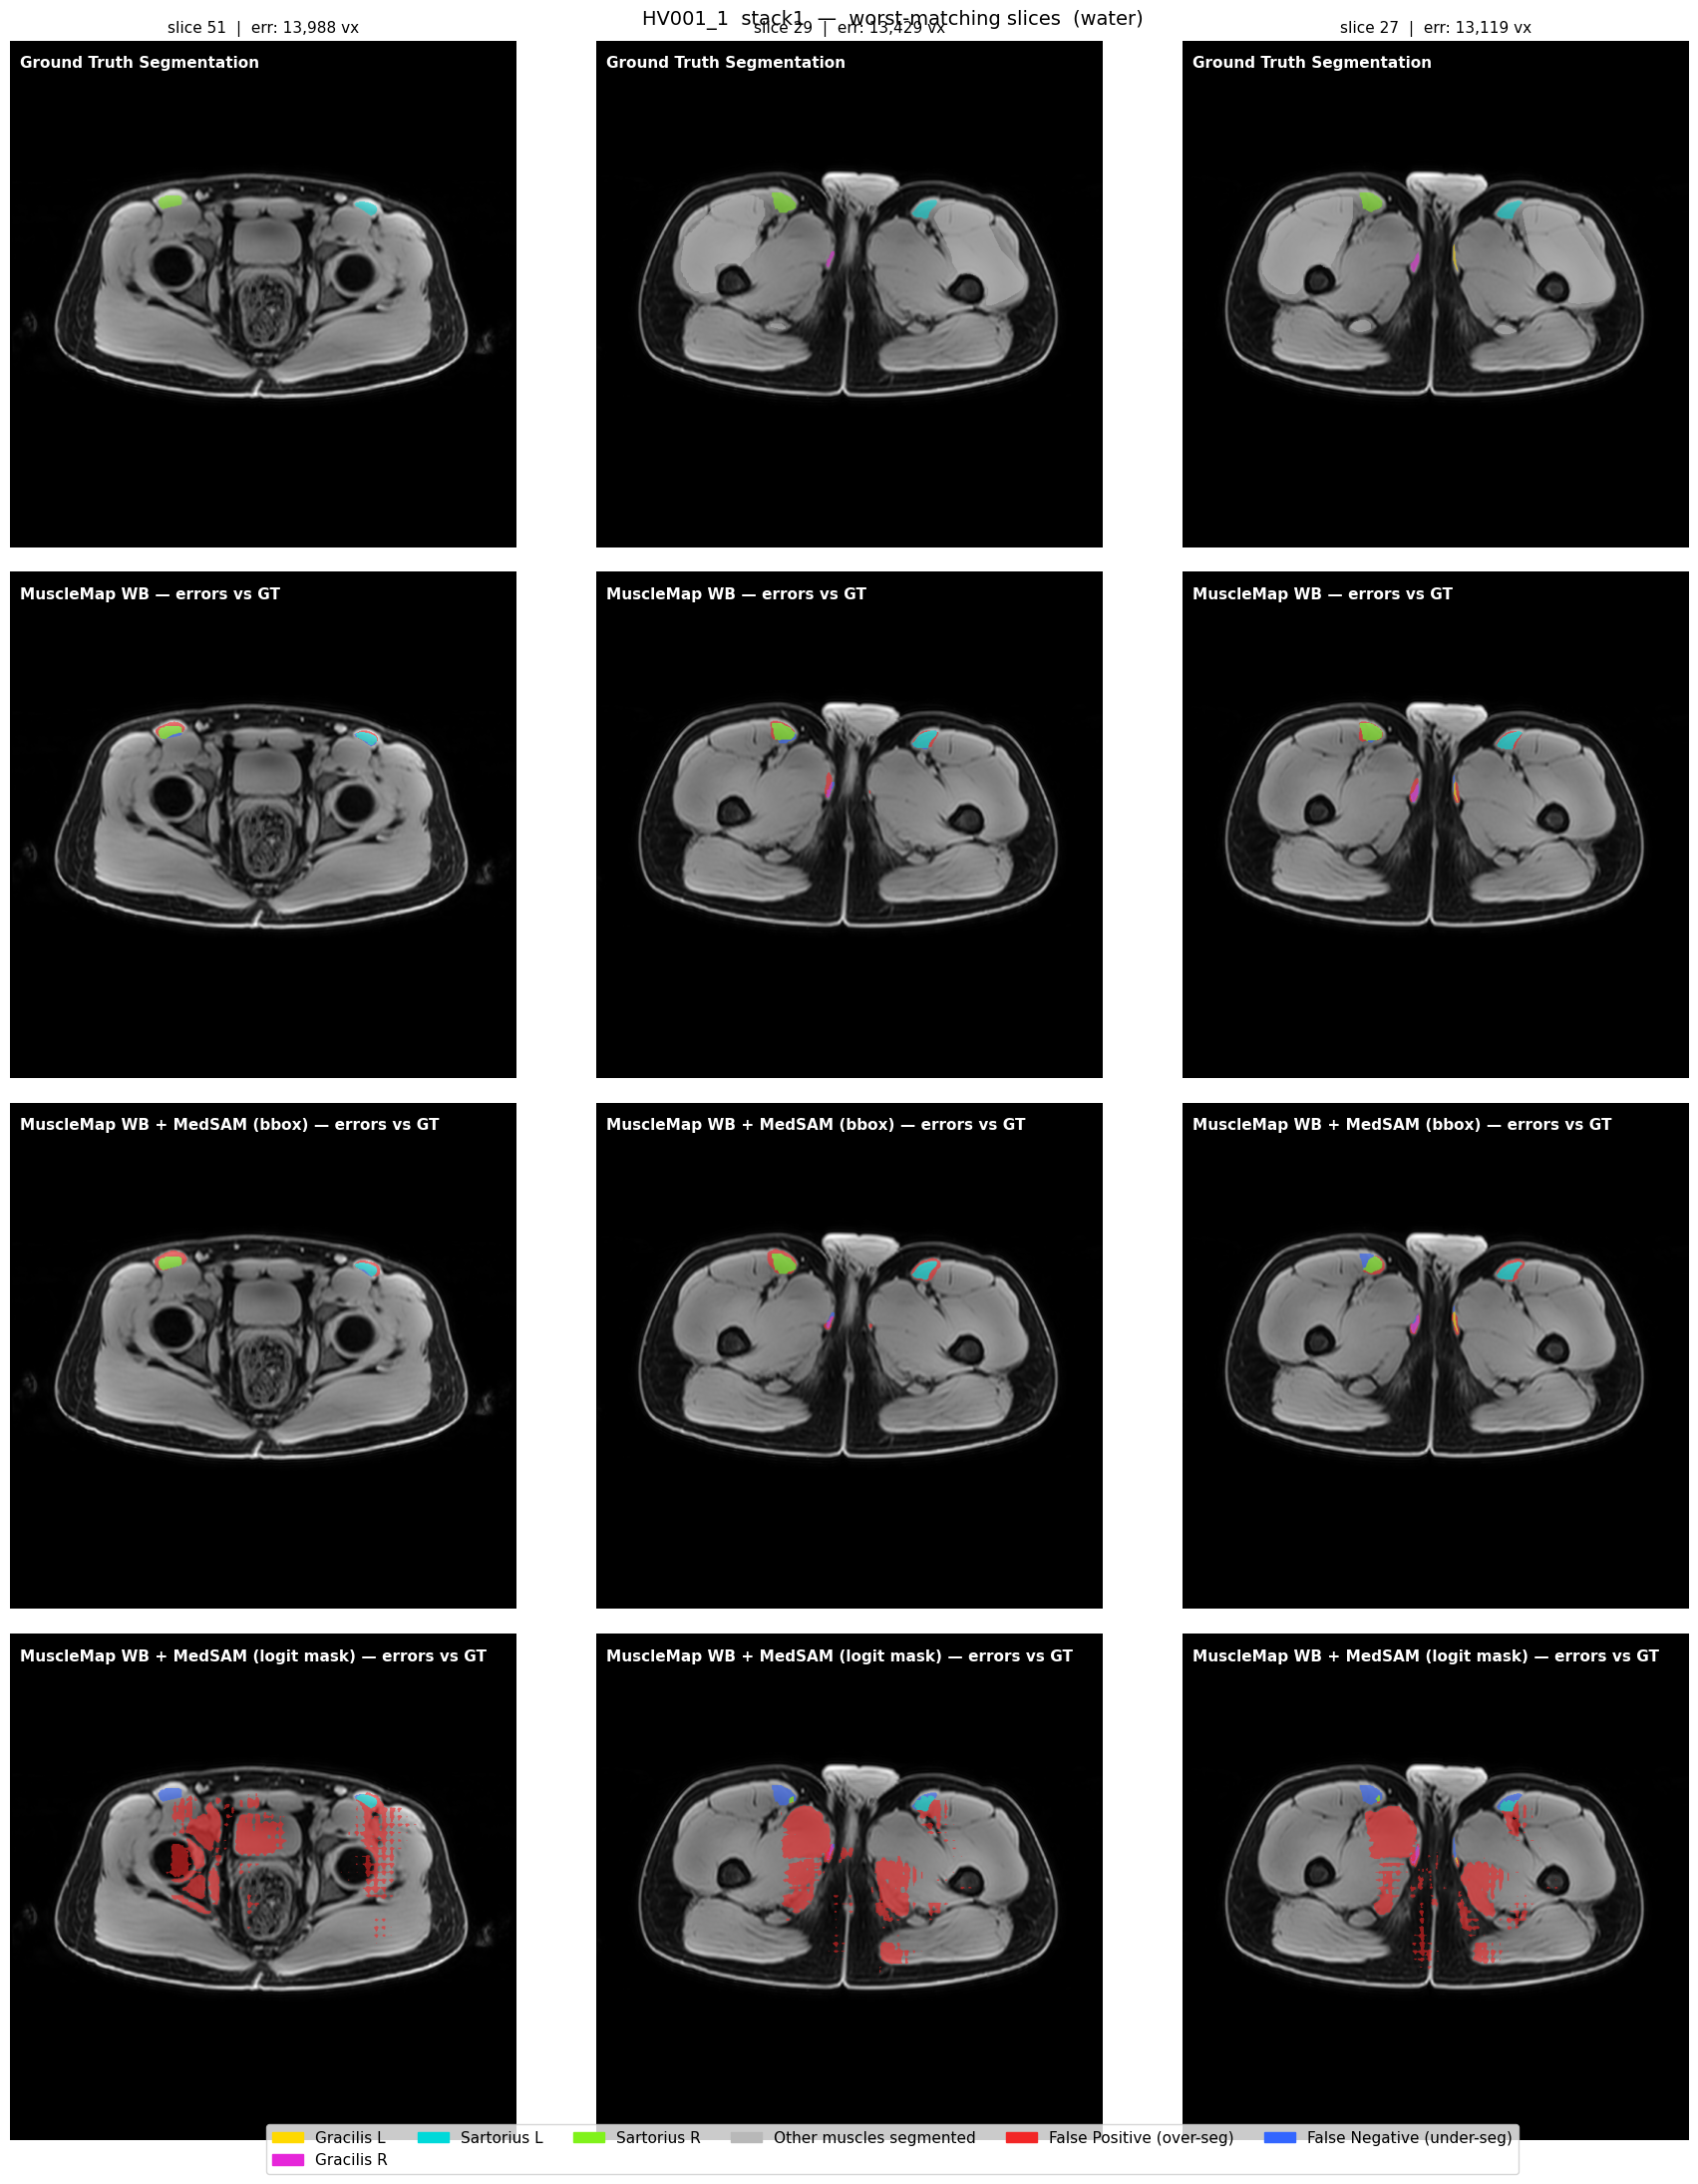

In [16]:
# ── Mismatch visualisation — 4 rows: GT, MM err, bbox SAM err, logitmask SAM err

def get_npz_slice(npz, key, sl_idx):
    if key in npz.files:
        return npz[key][sl_idx].astype(bool)
    return np.zeros(npz[npz.files[0]].shape[1:], dtype=bool)


def disagreement_per_slice(gt_vol, mm_vol, npz_data, muscles):
    D = gt_vol.shape[0]
    mm_err  = np.zeros(D, dtype=int)
    sam_err = np.zeros(D, dtype=int)
    for name, m in muscles.items():
        gt_bin  = (gt_vol == m['gt'])
        mm_bin  = (mm_vol == m['mm'])
        sam_bin = np.stack([get_npz_slice(npz_data, m['sam'], i) for i in range(D)])
        mm_err  += ((mm_bin  & ~gt_bin) | (~mm_bin  & gt_bin)).sum(axis=(1, 2))
        sam_err += ((sam_bin & ~gt_bin) | (~sam_bin & gt_bin)).sum(axis=(1, 2))
    return mm_err, sam_err


def error_overlay(img_2d, gt_2d, pred_masks_by_name, muscles, alpha=0.6):
    img_norm = (img_2d - img_2d.min()) / (img_2d.max() - img_2d.min() + 1e-8)
    out = np.stack([img_norm] * 3, axis=-1).copy()
    for name, m in muscles.items():
        gt_mask   = gt_2d == m['gt']
        pred_mask = pred_masks_by_name.get(name, np.zeros_like(gt_mask))
        tp = gt_mask  &  pred_mask
        fp = ~gt_mask &  pred_mask
        fn = gt_mask  & ~pred_mask
        for mask, color in [(tp, m['color']), (fp, FP_COLOR), (fn, FN_COLOR)]:
            if not mask.any():
                continue
            for c in range(3):
                out[mask, c] = out[mask, c] * (1 - alpha) + color[c] * alpha
    return np.clip(out, 0, 1)


mm_err, sam_err = disagreement_per_slice(gt, mm, npz, MUSCLES)
_, mask_err     = disagreement_per_slice(gt, mm, npz_mask, MUSCLES)
combined_err    = mm_err + sam_err + mask_err

valid_slices = np.where(gt_counts > 0)[0]
worst_idxs   = valid_slices[np.argsort(combined_err[valid_slices])[::-1][:3]]
print('Worst slices:', worst_idxs.tolist())

row_info = [
    'Ground Truth Segmentation',
    'MuscleMap WB — errors vs GT',
    'MuscleMap WB + MedSAM (bbox) — errors vs GT',
    'MuscleMap WB + MedSAM (logit mask) — errors vs GT',
]

fig, axes = plt.subplots(4, len(worst_idxs), figsize=(6 * len(worst_idxs), 22))

for col, sl_idx in enumerate(worst_idxs):
    sl_idx = int(sl_idx)
    i_sl, gt_sl, mm_sl = img[sl_idx], gt[sl_idx], mm[sl_idx]

    gt_rgb       = blend_overlay(i_sl, gt_masks_colors(gt_sl), ALPHA)
    mm_pred      = {name: mm_sl == m['mm']                       for name, m in MUSCLES.items()}
    sam_pred     = {name: get_npz_slice(npz,      m['sam'], sl_idx) for name, m in MUSCLES.items()}
    mask_pred    = {name: get_npz_slice(npz_mask, m['sam'], sl_idx) for name, m in MUSCLES.items()}
    mm_err_rgb   = error_overlay(i_sl, gt_sl, mm_pred,   MUSCLES)
    sam_err_rgb  = error_overlay(i_sl, gt_sl, sam_pred,  MUSCLES)
    mask_err_rgb = error_overlay(i_sl, gt_sl, mask_pred, MUSCLES)

    for row, (rgb, row_label) in enumerate(
            zip([gt_rgb, mm_err_rgb, sam_err_rgb, mask_err_rgb], row_info)):
        ax = axes[row][col]
        ax.imshow(rgb, origin='upper')
        ax.axis('off')
        label_ax(ax, row_label)
        if row == 0:
            ax.set_title(f'slice {sl_idx}  |  err: {combined_err[sl_idx]:,} vx',
                         fontsize=11, pad=6)

muscle_patches = [mpatches.Patch(color=m['color'], label=name) for name, m in MUSCLES.items()]
muscle_patches.append(mpatches.Patch(color=OTHER_COLOR, label='Other muscles segmented'))
error_patches  = [mpatches.Patch(color=FP_COLOR, label='False Positive (over-seg)'),
                  mpatches.Patch(color=FN_COLOR, label='False Negative (under-seg)')]
fig.legend(handles=muscle_patches + error_patches,
           loc='lower center', ncol=6, fontsize=11, bbox_to_anchor=(0.5, -0.01))
plt.suptitle(f'{SUBJECT}  stack{STACK}  —  worst-matching slices  (water)', fontsize=14)
plt.tight_layout()
out_png3 = f'comparison_{SUBJECT}_stack{STACK}_mismatch.png'
plt.savefig(out_png3, dpi=130, bbox_inches='tight')
print('Saved:', out_png3)
plt.show()

Worst slice: 51  (combined err=13,988 vx)
Saved: comparison_HV001_1_stack1_worst_slice51_grid.png


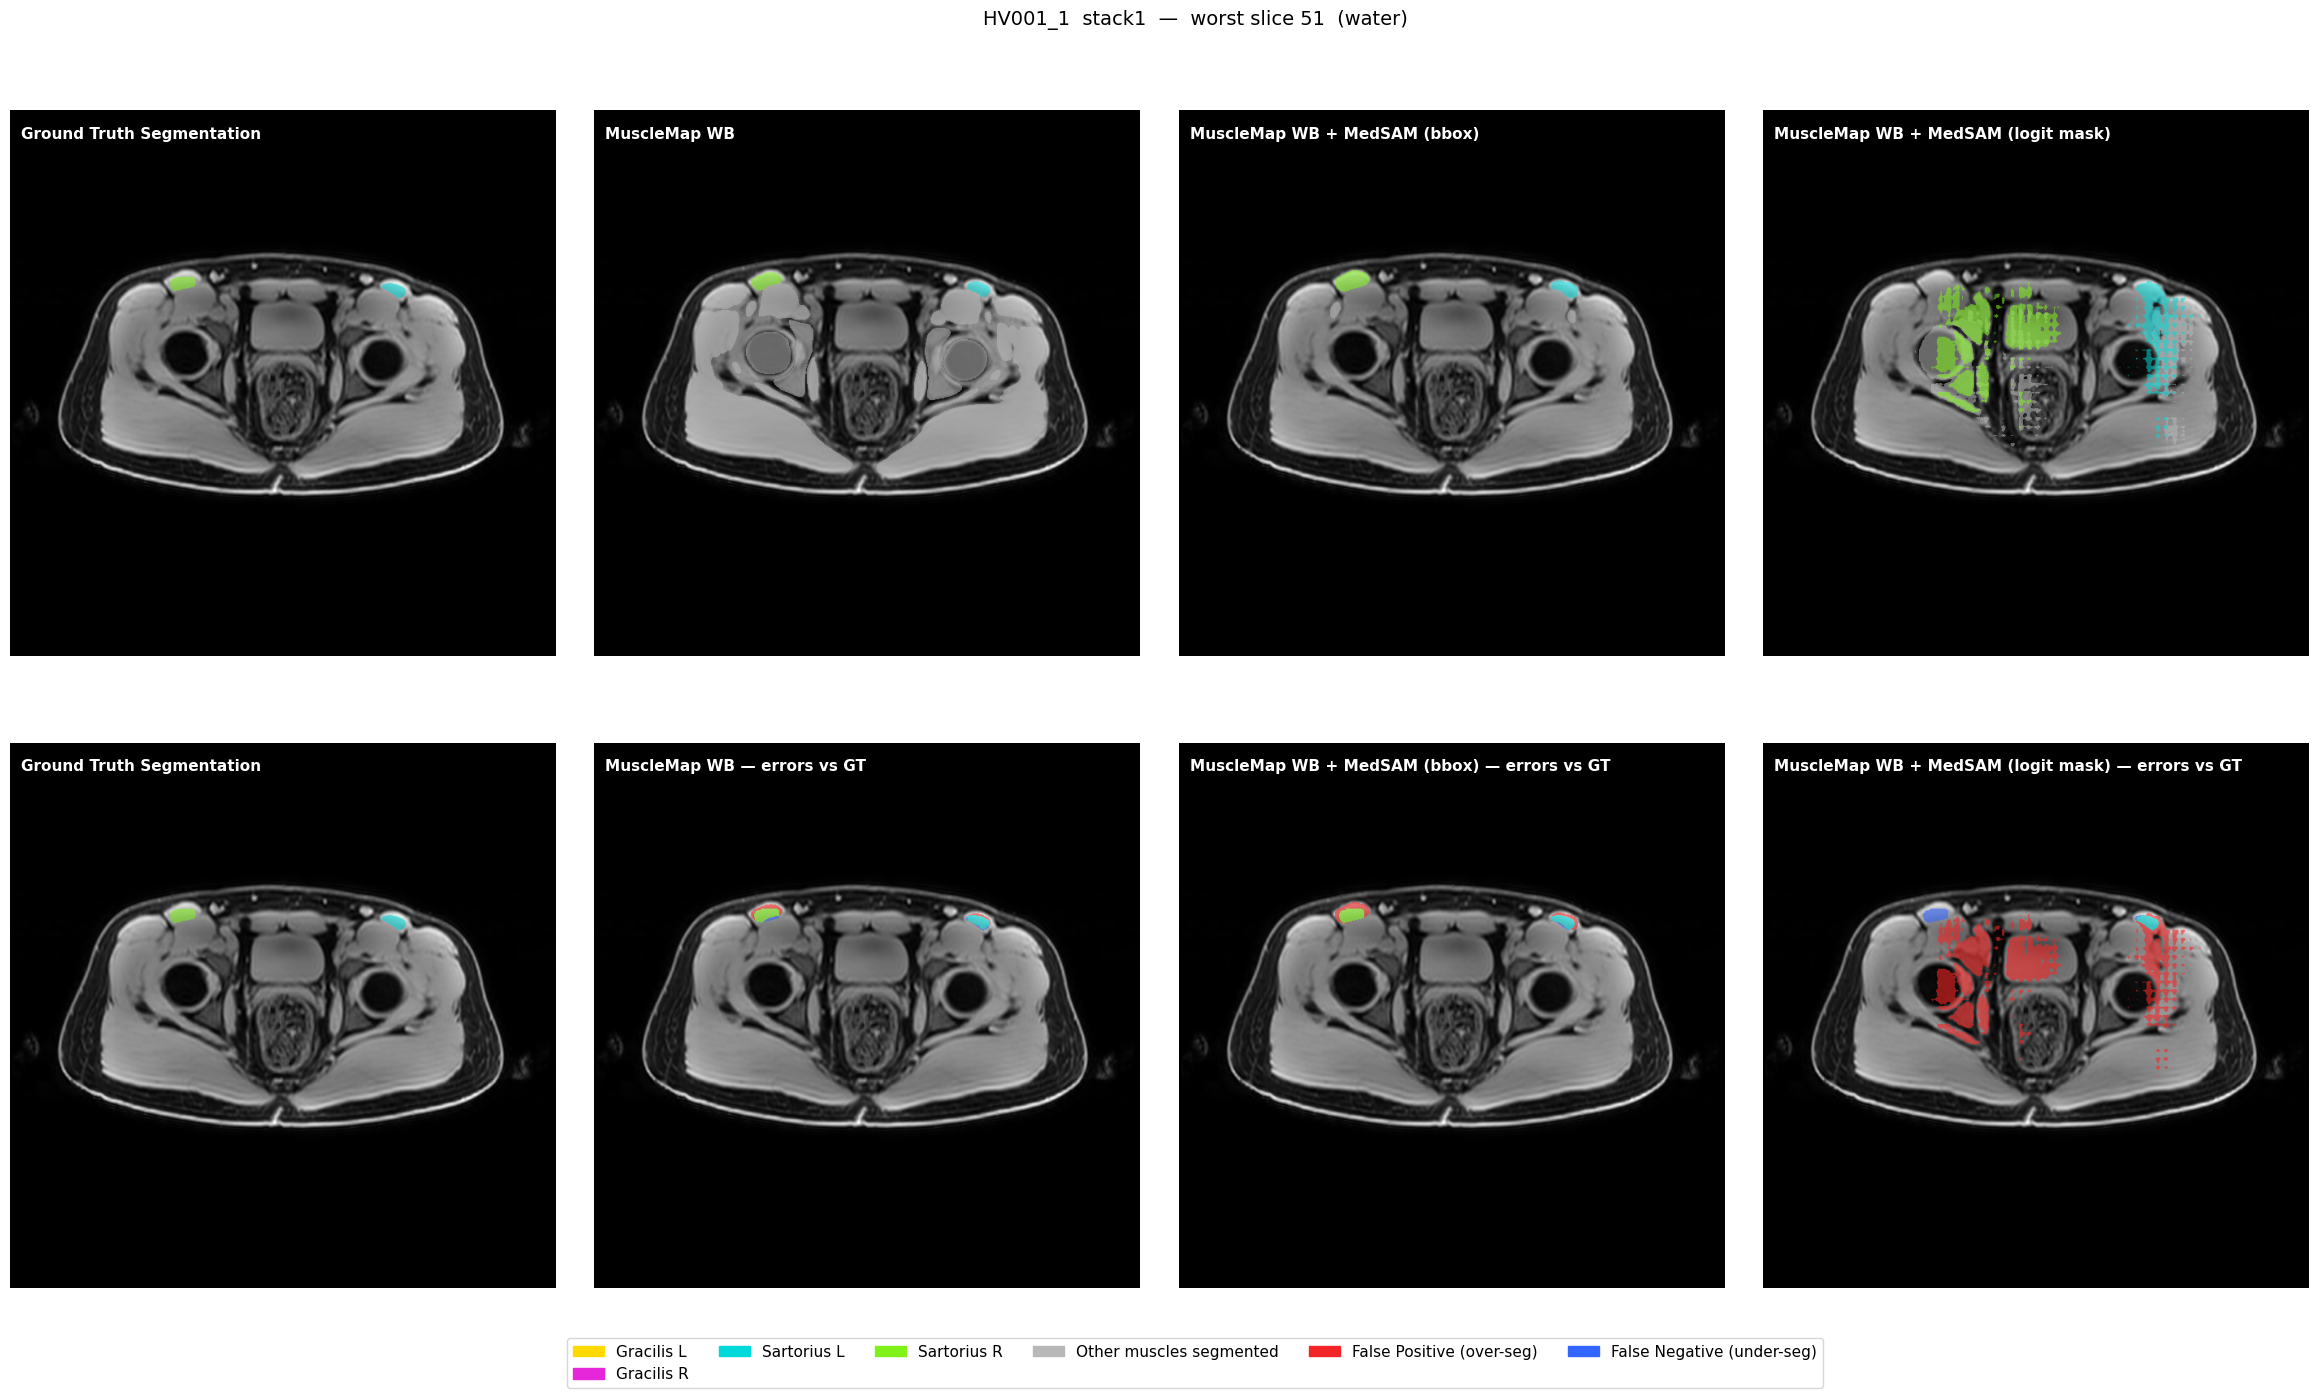

In [17]:
# ── Worst slice — 4×2 grid (top: plain overlay, bottom: FP/FN errors) ────
worst_slice = int(worst_idxs[0])
print(f'Worst slice: {worst_slice}  (combined err={combined_err[worst_slice]:,} vx)')

img_ws = img[worst_slice]
gt_ws  = gt[worst_slice]
mm_ws  = mm[worst_slice]

# Plain overlays (top row)
gt_rgb_w   = blend_overlay(img_ws, gt_masks_colors(gt_ws),                  ALPHA)
mm_rgb_w   = blend_overlay(img_ws, mm_masks_colors(mm_ws),                  ALPHA)
sam_rgb_w  = blend_overlay(img_ws, sam_masks_colors(npz,       worst_slice), ALPHA)
mask_rgb_w = blend_overlay(img_ws, sam_masks_colors(npz_mask,  worst_slice), ALPHA)

# Error overlays (bottom row)
mm_pred_w   = {name: mm_ws == m['mm']                               for name, m in MUSCLES.items()}
sam_pred_w  = {name: get_npz_slice(npz,      m['sam'], worst_slice) for name, m in MUSCLES.items()}
mask_pred_w = {name: get_npz_slice(npz_mask, m['sam'], worst_slice) for name, m in MUSCLES.items()}
mm_err_rgb_w   = error_overlay(img_ws, gt_ws, mm_pred_w,   MUSCLES)
sam_err_rgb_w  = error_overlay(img_ws, gt_ws, sam_pred_w,  MUSCLES)
mask_err_rgb_w = error_overlay(img_ws, gt_ws, mask_pred_w, MUSCLES)

col_labels = [
    'Ground Truth Segmentation',
    'MuscleMap WB',
    'MuscleMap WB + MedSAM (bbox)',
    'MuscleMap WB + MedSAM (logit mask)',
]
top_row    = [gt_rgb_w,   mm_rgb_w,      sam_rgb_w,      mask_rgb_w]
bottom_row = [gt_rgb_w,   mm_err_rgb_w,  sam_err_rgb_w,  mask_err_rgb_w]
bottom_labels = [
    'Ground Truth Segmentation',
    'MuscleMap WB — errors vs GT',
    'MuscleMap WB + MedSAM (bbox) — errors vs GT',
    'MuscleMap WB + MedSAM (logit mask) — errors vs GT',
]

fig, axes = plt.subplots(2, 4, figsize=(24, 14))
for col, (rgb, label) in enumerate(zip(top_row, col_labels)):
    axes[0][col].imshow(rgb, origin='upper')
    axes[0][col].axis('off')
    label_ax(axes[0][col], label)

for col, (rgb, label) in enumerate(zip(bottom_row, bottom_labels)):
    axes[1][col].imshow(rgb, origin='upper')
    axes[1][col].axis('off')
    label_ax(axes[1][col], label)

muscle_patches = [mpatches.Patch(color=m['color'], label=name) for name, m in MUSCLES.items()]
muscle_patches.append(mpatches.Patch(color=OTHER_COLOR, label='Other muscles segmented'))
error_patches  = [mpatches.Patch(color=FP_COLOR, label='False Positive (over-seg)'),
                  mpatches.Patch(color=FN_COLOR, label='False Negative (under-seg)')]
fig.legend(handles=muscle_patches + error_patches,
           loc='lower center', ncol=6, fontsize=11, bbox_to_anchor=(0.5, -0.01))

plt.suptitle(f'{SUBJECT}  stack{STACK}  —  worst slice {worst_slice}  (water)', fontsize=14)
plt.tight_layout()
out_png_w = f'comparison_{SUBJECT}_stack{STACK}_worst_slice{worst_slice}_grid.png'
plt.savefig(out_png_w, dpi=150, bbox_inches='tight')
print('Saved:', out_png_w)
plt.show()

Chosen slice: 3  (combined err=8,367)
Saved: comparison_HV001_1_stack1_ff_slice3.png


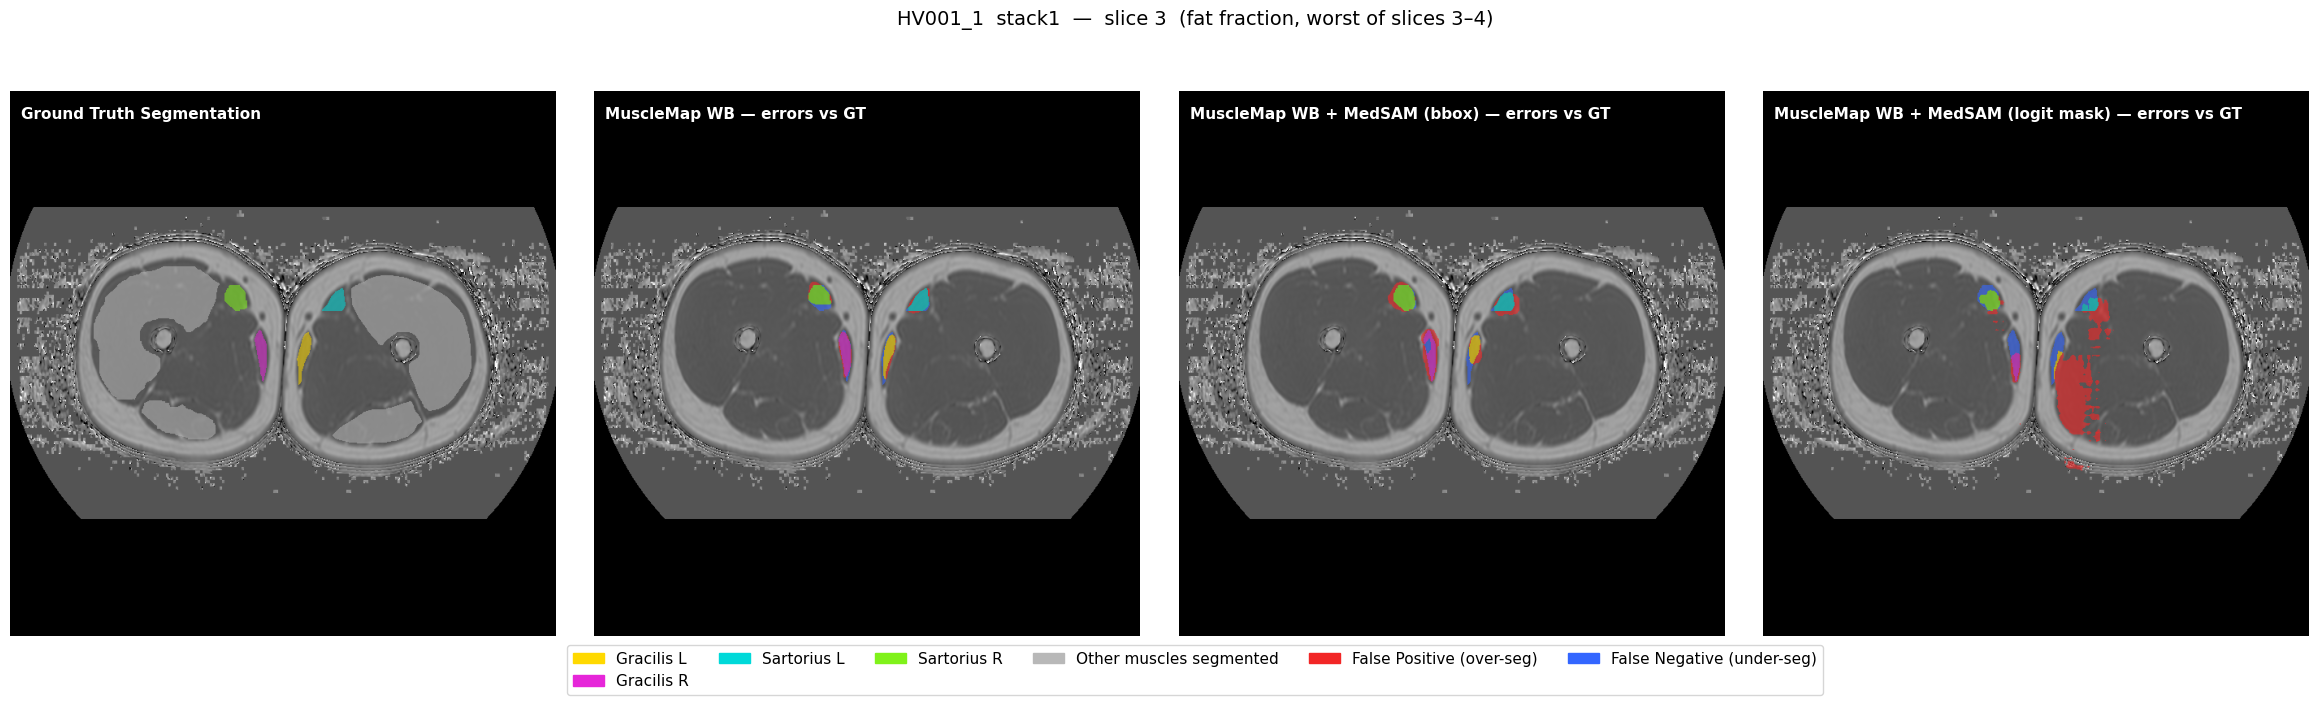

In [18]:
# ── Fat Fraction — single worst-mismatched slice (3 or 4), 4 panels ──────

FF_IMAGE_PATH = rf'{EVAL_DIR}\myosegmenTUM\{SUBJECT}\ImageData\{SUBJECT}_FATFRACTION\{SUBJECT}_FATFRACTION_stack{STACK}.nii'
FF_MM_PATH    = rf'{EVAL_DIR}\muscle_map_wb\segmentations_fat_frac\{SUBJECT}_FATFRACTION_stack{STACK}_dseg.nii.gz'
FF_SAM_PATH   = rf'{EVAL_DIR}\muscle_map_wb_boxes_medsam\segmentation_fat_fraction\{SUBJECT}_FATFRACTION_stack{STACK}_mm_medsam.npz'
FF_MASK_PATH  = rf'{EVAL_DIR}\muscle_map_wb_masks_medsam\segmentations_fat_fraction\{SUBJECT}_FATFRACTION_stack{STACK}_mm_logitmask.npz'

img_ff     = sitk.GetArrayFromImage(sitk.ReadImage(FF_IMAGE_PATH)).astype(float)
gt_ff      = sitk.GetArrayFromImage(sitk.ReadImage(GT_PATH)).astype(int)
mm_ff      = sitk.GetArrayFromImage(sitk.ReadImage(FF_MM_PATH)).astype(int)
npz_ff     = np.load(FF_SAM_PATH)
npz_mask_ff = np.load(FF_MASK_PATH)

# Pick slice 3 or 4 — whichever has more combined FP+FN across all sources
mm_err_ff,   sam_err_ff  = disagreement_per_slice(gt_ff, mm_ff, npz_ff,      MUSCLES)
_,           mask_err_ff = disagreement_per_slice(gt_ff, mm_ff, npz_mask_ff, MUSCLES)
combined_ff  = mm_err_ff + sam_err_ff + mask_err_ff
sl_idx = 3 if combined_ff[3] >= combined_ff[4] else 4
print(f'Chosen slice: {sl_idx}  (combined err={combined_ff[sl_idx]:,})')

i_sl  = img_ff[sl_idx]
gt_sl = gt_ff[sl_idx]
mm_sl = mm_ff[sl_idx]

gt_rgb       = blend_overlay(i_sl, gt_masks_colors(gt_sl), ALPHA)
mm_pred      = {name: mm_sl == m['mm']                         for name, m in MUSCLES.items()}
sam_pred     = {name: get_npz_slice(npz_ff,      m['sam'], sl_idx) for name, m in MUSCLES.items()}
mask_pred    = {name: get_npz_slice(npz_mask_ff, m['sam'], sl_idx) for name, m in MUSCLES.items()}
mm_err_rgb   = error_overlay(i_sl, gt_sl, mm_pred,   MUSCLES)
sam_err_rgb  = error_overlay(i_sl, gt_sl, sam_pred,  MUSCLES)
mask_err_rgb = error_overlay(i_sl, gt_sl, mask_pred, MUSCLES)

fig, axes = plt.subplots(1, 4, figsize=(24, 7))
for ax, rgb, label in zip(axes,
        [gt_rgb, mm_err_rgb, sam_err_rgb, mask_err_rgb],
        ['Ground Truth Segmentation',
         'MuscleMap WB — errors vs GT',
         'MuscleMap WB + MedSAM (bbox) — errors vs GT',
         'MuscleMap WB + MedSAM (logit mask) — errors vs GT']):
    ax.imshow(rgb, origin='upper')
    ax.axis('off')
    label_ax(ax, label)

muscle_patches = [mpatches.Patch(color=m['color'], label=name) for name, m in MUSCLES.items()]
muscle_patches.append(mpatches.Patch(color=OTHER_COLOR, label='Other muscles segmented'))
error_patches  = [mpatches.Patch(color=FP_COLOR, label='False Positive (over-seg)'),
                  mpatches.Patch(color=FN_COLOR, label='False Negative (under-seg)')]
fig.legend(handles=muscle_patches + error_patches,
           loc='lower center', ncol=6, fontsize=11, bbox_to_anchor=(0.5, -0.01))
plt.suptitle(f'{SUBJECT}  stack{STACK}  —  slice {sl_idx}  (fat fraction, worst of slices 3–4)', fontsize=14)
plt.tight_layout()
out_ff = f'comparison_{SUBJECT}_stack{STACK}_ff_slice{sl_idx}.png'
plt.savefig(out_ff, dpi=150, bbox_inches='tight')
print('Saved:', out_ff)
plt.show()